<a href="https://colab.research.google.com/github/gokulgpn/remote-sensing-portfolio/blob/main/juaboso-deforestation-risk/notebooks/03_juaboso_cocoa_risk_screening.ipynbjuaboso-deforestation-risk/notebooks/03_juaboso_cocoa_risk_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Juaboso Cocoa-Linked Tree-Cover Risk Screening

This notebook is a **continuation of the Juaboso 2020–2024 tree-cover change analysis**.

The previous notebook identified **1,359.30 ha (13.59 km²)** of candidate tree-cover loss and exported:

- `juaboso_tree_cover_change_2020_2024.gpkg` — vector change polygons
- `juaboso_tree_cover_loss_2020_2024.tif` — exact 10 m binary raster mask

This notebook combines those candidate-loss areas with the **Forest Data Partnership 2024 cocoa probability layer** from Google Earth Engine.

### Objective

Identify how much of the candidate post-2020 tree-cover-loss area overlaps locations with elevated modeled cocoa probability.

This is a **screening workflow**, not proof that cocoa caused the observed tree-cover loss and not a determination of EUDR non-compliance.


## 1. Setup


In [1]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

use_google_drive = True

if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_path = '/content/drive/MyDrive/python-remote-sensing'
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

os.makedirs(data_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')


Mounted at /content/drive
Environment: colab
Data folder: /content/drive/MyDrive/python-remote-sensing
Output folder: /content/drive/MyDrive/python-remote-sensing


In [23]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install earthengine-api geopandas matplotlib pandas rioxarray rasterio

In [24]:
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray as rxr

## 2. Load the Juaboso AOI and candidate tree-cover-loss polygons

The previous notebook exported the filtered 2020–2024 candidate tree-cover-loss polygons as `juaboso_tree_cover_change_2020_2024.gpkg`.

In [11]:
aoi_filepath = os.path.join(
    data_folder,
    'aoi.geojson'
)

change_filepath = os.path.join(
    data_folder,
    'juaboso_tree_cover_change_2020_2024.gpkg'
)

change_raster_filepath = os.path.join(
    data_folder,
    'juaboso_tree_cover_loss_2020_2024.tif'
)

if not os.path.exists(aoi_filepath):
    raise FileNotFoundError(
        f'Juaboso AOI not found: {aoi_filepath}'
    )

if not os.path.exists(change_filepath):
    raise FileNotFoundError(
        f'Candidate tree-cover change polygons not found: {change_filepath}'
    )

aoi_gdf = gpd.read_file(aoi_filepath)
change_gdf = gpd.read_file(change_filepath)

print(f'Candidate change polygons: {len(change_gdf):,}')
print(f'Change CRS: {change_gdf.crs}')

if os.path.exists(change_raster_filepath):
    print(
        f'10 m tree-cover loss raster found: '
        f'{change_raster_filepath}'
    )
else:
    print(
        '10 m tree-cover loss raster not found; '
        'vector polygons will still be used for screening.'
    )

change_gdf.head()

Candidate change polygons: 218
Change CRS: EPSG:32630
10 m tree-cover loss raster found: /content/drive/MyDrive/python-remote-sensing/juaboso_tree_cover_loss_2020_2024.tif


,DN,geometry
0,1,"POLYGON ((513190 734430, 513230 734430, 513230..."
1,1,"POLYGON ((513370 733970, 513380 733970, 513380..."
2,1,"POLYGON ((518270 733410, 518290 733410, 518290..."
3,1,"POLYGON ((518530 732980, 518570 732980, 518570..."
4,1,"POLYGON ((519390 732360, 519400 732360, 519400..."


In [12]:
import os

drive_path = '/content/drive/MyDrive/python-remote-sensing'
if os.path.exists(drive_path):
    print("Files in directory:")
    for f in os.listdir(drive_path):
        print(f" - {f}")
else:
    print(f"Directory does not exist: {drive_path}")

Files in directory:
 - aoi.geojson
 - esa_worldcover_original.tif
 - esa_worldcover_colormap.tif
 - aoi_class_areas.csv
 - glad_glcuc_colormap.tif
 - juaboso_tree_cover_loss_2020_2024.tif
 - juaboso_tree_cover_change_2020_2024.gpkg
 - .ipynb_checkpoints


In [13]:
# Total candidate tree-cover-loss area from the previous notebook
LOSS_AREA_HA = 1359.30
LOSS_AREA_KM2 = 13.59

print(f'Candidate tree-cover loss: {LOSS_AREA_HA:,.2f} ha ({LOSS_AREA_KM2:.2f} km²)')


Candidate tree-cover loss: 1,359.30 ha (13.59 km²)


## 3. Initialize Google Earth Engine


In [14]:
PROJECT_ID = 'ee-gokulgpn70'

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print('Earth Engine initialized.')


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine initialized.


## Spatial resolution and data model

Both inputs are handled at **10 m spatial resolution**:

- **Tree-cover change raster:** binary change mask at 10 m; each pixel ≈ 100 m²
- **Cocoa probability layer:** continuous probability raster at 10 m, with values from 0 to 1

Although both datasets operate at the same spatial scale, they represent different information:

- the tree-cover change product identifies **where tree cover changed**
- the cocoa product estimates **how likely cocoa is at a location**

For the final screening statistics, the existing **change polygons** are used as the analysis geometry and Earth Engine calculates cocoa probability directly inside those areas. The 10 m GeoTIFF is retained as the exact raster output for QGIS, validation and archival use. This avoids downloading or resampling the full cocoa raster locally.


## 4. Load the Forest Data Partnership cocoa probability layer

The 2024 Forest Data Partnership cocoa layer is accessed directly from Google Earth Engine.

It is treated as a **10 m continuous probability surface**. Values closer to 1 indicate higher modeled cocoa probability.


In [15]:
cocoa_collection = ee.ImageCollection(
    'projects/forestdatapartnership/assets/cocoa/model_2026a'
)

cocoa_2024 = (
    cocoa_collection
    .filterDate('2024-01-01', '2025-01-01')
    .mosaic()
    .select('probability')
)

print('2024 cocoa probability image prepared.')


2024 cocoa probability image prepared.


## 5. Convert the candidate-loss polygons to an Earth Engine geometry

For this screening step we use the existing vector polygons directly.  
This avoids downloading and resampling the full cocoa raster locally.


In [16]:
# Reproject to WGS84 before sending geometry to Earth Engine
loss_gdf_wgs84 = change_gdf.to_crs('EPSG:4326')

# Dissolve all candidate-loss polygons into one geometry
loss_geometry = loss_gdf_wgs84.geometry.union_all()

ee_loss_geometry = ee.Geometry(loss_geometry.__geo_interface__)

print('Candidate tree-cover-loss geometry prepared for Earth Engine.')


Candidate tree-cover-loss geometry prepared for Earth Engine.


## 6. Cocoa probability inside candidate tree-cover-loss areas


In [17]:
mean_cocoa = cocoa_2024.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ee_loss_geometry,
    scale=10,
    maxPixels=1e9,
    bestEffort=True
).get('probability')

mean_cocoa_value = ee.Number(mean_cocoa).getInfo()

print(f'Mean cocoa probability within candidate tree-cover loss: {mean_cocoa_value:.3f}')


Mean cocoa probability within candidate tree-cover loss: 0.073


## 7. Screening thresholds

Two transparent screening thresholds are used:

- **≥ 0.50**: moderate-or-higher modeled cocoa probability
- **≥ 0.75**: high modeled cocoa probability

These are prioritization thresholds for this portfolio analysis, not validated cocoa-classification cutoffs.


In [33]:
pixel_area = ee.Image.pixelArea()

moderate_mask = cocoa_2024.gte(0.50)
high_mask = cocoa_2024.gte(0.75)

moderate_area_m2 = (
    moderate_mask
    .multiply(pixel_area)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ee_loss_geometry,
        scale=10,
        maxPixels=1e9,
        tileScale=4
    )
    .get('probability')
)

high_area_m2 = (
    high_mask
    .multiply(pixel_area)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ee_loss_geometry,
        scale=10,
        maxPixels=1e9,
        tileScale=4
    )
    .get('probability')
)

moderate_area_ha = ee.Number(moderate_area_m2).divide(10000).getInfo()
high_area_ha = ee.Number(high_area_m2).divide(10000).getInfo()

moderate_pct = moderate_area_ha / LOSS_AREA_HA * 100
high_pct = high_area_ha / LOSS_AREA_HA * 100

print(f'>= 0.50: {moderate_area_ha:.2f} ha ({moderate_pct:.2f}%)')
print(f'>= 0.75: {high_area_ha:.2f} ha ({high_pct:.2f}%)')

>= 0.50: 99.02 ha (7.28%)
>= 0.75: 60.95 ha (4.48%)


## 8. Summary table


In [34]:
summary = pd.DataFrame({
    'Metric': [
        'Candidate tree-cover loss',
        'Overlap with cocoa probability ≥ 0.50',
        'Overlap with cocoa probability ≥ 0.75'
    ],
    'Area_ha': [
        LOSS_AREA_HA,
        moderate_area_ha,
        high_area_ha
    ],
    'Share_of_candidate_loss_pct': [
        100.0,
        moderate_pct,
        high_pct
    ]
})

summary


,Metric,Area_ha,Share_of_candidate_loss_pct
0,Candidate tree-cover loss,1359.300000,100.000000
1,Overlap with cocoa probability ≥ 0.50,99.015098,7.284271
2,Overlap with cocoa probability ≥ 0.75,60.951584,4.484042


In [36]:
# ------------------------------------------------------------
# 9. Create final high cocoa-probability overlap raster
# ------------------------------------------------------------

# High cocoa-probability threshold
HIGH_THRESHOLD = 0.75

# Binary mask: 1 where cocoa probability >= 0.75
high_cocoa_mask = cocoa_2024.gte(HIGH_THRESHOLD)

# Keep only pixels inside the candidate tree-cover-loss geometry
cocoa_linked_risk = (
    high_cocoa_mask
    .clip(ee_loss_geometry)
    .selfMask()
    .rename('high_cocoa_tree_loss_overlap')
)

print('Final high cocoa-probability overlap raster created.')

Final high cocoa-probability overlap raster created.


In [37]:
# ------------------------------------------------------------
# 10. Export final overlap raster to Google Drive
# ------------------------------------------------------------

export_task = ee.batch.Export.image.toDrive(
    image=cocoa_linked_risk,
    description='Juaboso_High_Cocoa_Tree_Loss_Overlap_2020_2024',
    folder='python-remote-sensing',
    fileNamePrefix='juaboso_high_cocoa_tree_loss_overlap_2020_2024',
    region=ee_loss_geometry,
    scale=10,
    crs='EPSG:32630',
    maxPixels=1e9
)

export_task.start()

print('Export started.')
print('Output filename: juaboso_high_cocoa_tree_loss_overlap_2020_2024.tif')

Export started.
Output filename: juaboso_high_cocoa_tree_loss_overlap_2020_2024.tif


In [39]:
export_task.status()

{'state': 'RUNNING',
 'description': 'Juaboso_High_Cocoa_Tree_Loss_Overlap_2020_2024',
 'priority': 100,
 'creation_timestamp_ms': 1791313346184,
 'update_timestamp_ms': 1791313348479,
 'start_timestamp_ms': 1791313348420,
 'task_type': 'EXPORT_IMAGE',
 'attempt': 1,
 'id': 'XPUPPPQSXB5NUAYKNZDIIEOD',
 'name': 'projects/ee-gokulgpn70/operations/XPUPPPQSXB5NUAYKNZDIIEOD'}

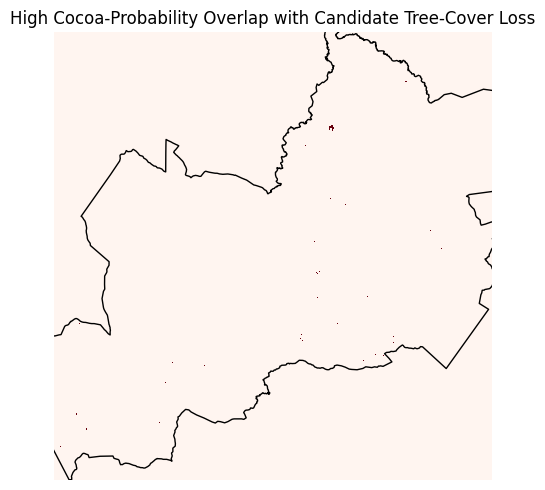

In [32]:
risk_raster = rxr.open_rasterio(
    os.path.join(
        output_folder,
        'juaboso_high_cocoa_tree_loss_overlap_2020_2024.tif'
    ),
    masked=True
).squeeze()

aoi_plot = aoi_gdf.to_crs(risk_raster.rio.crs)

fig, ax = plt.subplots(figsize=(5, 5))

risk_raster.plot(
    ax=ax,
    cmap='Reds',
    add_colorbar=False
)

aoi_plot.boundary.plot(
    ax=ax,
    color='black',
    linewidth=1
)

ax.set_title(
    'High Cocoa-Probability Overlap with Candidate Tree-Cover Loss'
)

ax.set_axis_off()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Interpretation

The overlap identifies **candidate commodity-linked risk areas** where post-2020 tree-cover loss coincides spatially with elevated modeled cocoa probability.

Because both inputs are evaluated at approximately **10 m spatial resolution**, the screening operates at a comparable spatial scale. However, matching resolution does **not** remove classification uncertainty or establish causality.

Spatial coincidence does **not** prove that cocoa production caused the observed tree-cover change. It should therefore be treated as a prioritization layer for further validation using higher-resolution optical imagery, SAR where cloud cover is problematic, temporal evidence of land-use conversion, and plot or supply-chain information where available.

This workflow demonstrates how a previously derived 10 m land-cover change product can be combined with a 10 m third-party commodity probability dataset using server-side Earth Engine analysis without transferring the full cocoa raster locally.
